In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:

df = pd.read_csv(r"C:\Games\final project\covid_binary_data.csv")

In [13]:
print(df.head())
df.info()
print(df.describe())

   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0        2        4        1        0        0        4       42       42   
1       55       72       70       75       87       80       81       78   
2        2        5        1        8        7        5        5        1   
3        0        0        0        0        0        0        0        0   
4        8        8        7        6        6        4        3        1   

   pixel_8  pixel_9  ...  pixel_2491  pixel_2492  pixel_2493  pixel_2494  \
0        1        2  ...         178         155          85          32   
1       81       86  ...         162         153         142         133   
2        1        4  ...         179         140         127          96   
3        0        0  ...         223         229         234         232   
4        0        2  ...         188         173         162          75   

   pixel_2495  pixel_2496  pixel_2497  pixel_2498  pixel_2499  Label  
0        

In [14]:
target_col = 'Label'
df.dropna(subset=[target_col], inplace=True) 


labels = df[target_col].astype(str).tolist()
X = df.drop(columns=[target_col])
X.columns = [f'pixel_{i}' for i in range(X.shape[1])]

In [15]:
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 11296, Testing samples: 2824


In [17]:
print("\n Accuracy Before Scaling & PCA ")
log_raw = LogisticRegression(max_iter=3000).fit(X_train, y_train)
svm_raw = SVC().fit(X_train, y_train)
tree_raw = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"Raw Logistic Accuracy: {accuracy_score(y_test, log_raw.predict(X_test)):.4f}")
print(f"Raw SVM Accuracy:      {accuracy_score(y_test, svm_raw.predict(X_test)):.4f}")
print(f"Raw Tree Accuracy:     {accuracy_score(y_test, tree_raw.predict(X_test)):.4f}")


 Accuracy Before Scaling & PCA 


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Raw Logistic Accuracy: 0.7971
Raw SVM Accuracy:      0.9164
Raw Tree Accuracy:     0.8576


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=0.98)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [19]:
print(f"\n PCA reduced features from {X_train.shape[1]} to {pca.n_components_} components.")

log_grid = GridSearchCV(LogisticRegression(max_iter=3000, class_weight='balanced'), 
                        {'C': [0.01, 0.1, 1, 10, 100]}, cv=3, n_jobs=-1)
log_grid.fit(X_train_pca, y_train)


 PCA reduced features from 2500 to 608 components.


,estimator,LogisticRegre...max_iter=3000)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'



 Logistic Regression  


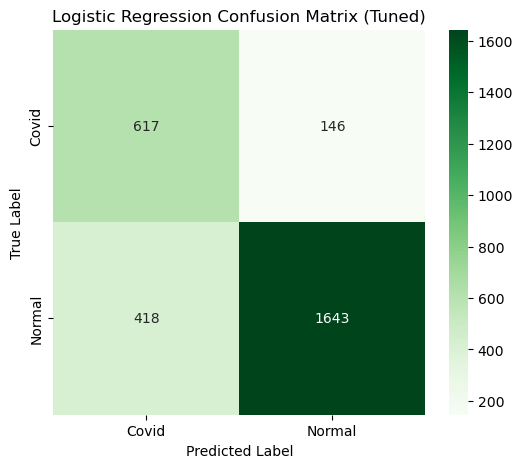

Tuned Logistic Accuracy: 0.8003


In [20]:
print("\n Logistic Regression  ")
y_pred_log = log_grid.predict(X_test_pca)
plt.figure(figsize=(6, 5))
matrix_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(matrix_log, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)

plt.title("Logistic Regression Confusion Matrix (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
print(f"Tuned Logistic Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

In [21]:
print("\n Tuning SVM ")
svm_grid = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42), 
    {'C': [0.1, 1, 10, 100], 'kernel': ['rbf']}, cv=3, n_jobs=-1
)
svm_grid.fit(X_train_pca, y_train)


 Tuning SVM...


,estimator,SVC(class_wei...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [22]:
tree_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5,10,15, 20,25, 30,35, None], 
    'min_samples_split': [2, 5, 10]
}
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'), 
                         tree_params, cv=3, n_jobs=-1)
tree_grid.fit(X_train_pca, y_train)
y_pred_tree = tree_grid.predict(X_test_pca)


Best Tree Params: {'criterion': 'entropy', 'max_depth': 25, 'min_samples_split': 5}
Tuned Tree Accuracy: 0.7847


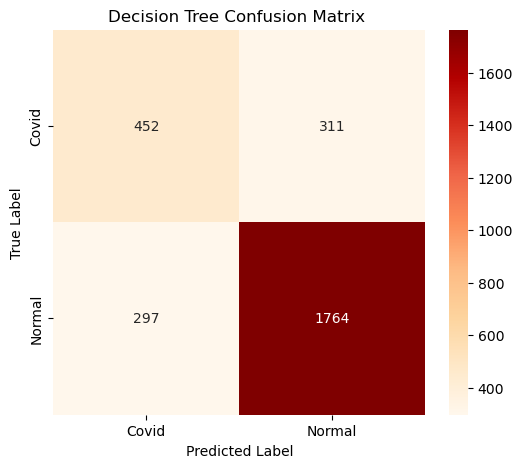

In [23]:
print(f"\nBest Tree Params: {tree_grid.best_params_}")
print(f"Tuned Tree Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

plt.figure(figsize=(6, 5))
matrix_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(matrix_tree, annot=True, fmt='d', cmap='OrRd', cbar=True,
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Decision Tree Confusion Matrix ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [24]:
print(f"\nBest Logistic Params: {log_grid.best_params_}")
print(f"Best SVM Params: {svm_grid.best_params_}")

models = {
    'Logistic': log_grid,
    'SVM': svm_grid,
    'Tree': tree_grid
}


Best Logistic Params: {'C': 0.1}
Best SVM Params: {'C': 10, 'kernel': 'rbf'}



  Final Model Selected: SVM 
Accuracy Score: 0.9451

Final Classification Report:
               precision    recall  f1-score   support

       Covid       0.89      0.91      0.90       763
      Normal       0.97      0.96      0.96      2061

    accuracy                           0.95      2824
   macro avg       0.93      0.94      0.93      2824
weighted avg       0.95      0.95      0.95      2824



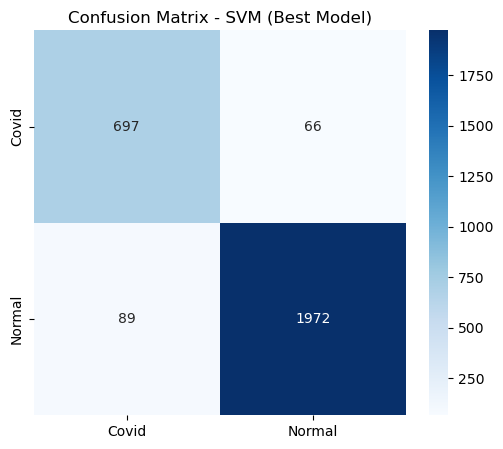


 Best model package saved as 'best_covid_model.pkl' using pickle.


In [25]:
best_name = max(models, key=lambda k: models[k].best_score_)
best_model = models[best_name].best_estimator_
print(f"\n  Final Model Selected: {best_name} ")
y_pred_final = best_model.predict(X_test_pca)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred_final, target_names=encoder.classes_))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f"Confusion Matrix - {best_name} (Best Model)")
plt.show()

model_filename = "best_covid_model.pkl"
export_data = {
    'model': best_model,
    'scaler': scaler,
    'pca': pca,
    'encoder': encoder
}
with open(model_filename, 'wb') as file:
    pickle.dump(export_data, file)

print(f"\n Best model package saved as '{model_filename}' using pickle.")